# Bonus B4 — Markowitz Efficient Frontier

## Objective

This analysis applies Modern Portfolio Theory (Markowitz Portfolio Optimization)
to five selected mutual funds.

The objective is to identify portfolios that provide different combinations of
expected return and risk and to identify the minimum-volatility and
maximum-Sharpe-ratio portfolios.

## Selected Funds

- SBI Bluechip
- ICICI Bluechip
- Nippon Large Cap
- Axis Bluechip
- Kotak Bluechip

## Methodology

Historical NAV data is used to calculate daily returns.

The analysis includes:

- Annualized expected returns
- Annualized covariance matrix
- Random portfolio generation
- Portfolio expected return
- Portfolio volatility
- Sharpe ratio
- Efficient frontier
- Optimal portfolio weights

> The optimization is based on historical data and does not guarantee future
> portfolio performance.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
PROJECT_ROOT = Path.cwd().parent

NAV_FILE = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "02_nav_history_cleaned.csv"
)

OUTPUT_DIR = PROJECT_ROOT / "outputs"
CHART_DIR = PROJECT_ROOT / "reports" / "charts"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CHART_DIR.mkdir(parents=True, exist_ok=True)

print("NAV file:", NAV_FILE)
print("Output directory:", OUTPUT_DIR)
print("Chart directory:", CHART_DIR)

NAV file: c:\Users\Keerthana\OneDrive\Documents\MutualFundAnalytics\data\processed\02_nav_history_cleaned.csv
Output directory: c:\Users\Keerthana\OneDrive\Documents\MutualFundAnalytics\outputs
Chart directory: c:\Users\Keerthana\OneDrive\Documents\MutualFundAnalytics\reports\charts


In [3]:
nav = pd.read_csv(NAV_FILE)

nav["date"] = pd.to_datetime(
    nav["date"],
    errors="coerce"
)

nav["nav"] = pd.to_numeric(
    nav["nav"],
    errors="coerce"
)

nav = nav.dropna(
    subset=["date", "nav"]
)

nav = nav[nav["nav"] > 0]

nav = nav.sort_values(
    ["amfi_code", "date"]
)

print("Rows:", len(nav))
print("Funds:", nav["amfi_code"].nunique())
print(nav.head())

Rows: 46000
Funds: 40
   amfi_code       date       nav
0     100016 2022-01-03  520.4608
1     100016 2022-01-04  515.0971
2     100016 2022-01-05  521.7239
3     100016 2022-01-06  515.7880
4     100016 2022-01-07  515.1639


In [4]:
selected_codes = [
    119551,  # SBI Bluechip
    120503,  # ICICI Bluechip
    118632,  # Nippon Large Cap
    119092,  # Axis Bluechip
    120841   # Kotak Bluechip
]

selected_nav = nav[
    nav["amfi_code"].isin(selected_codes)
].copy()

print("Selected funds:", selected_nav["amfi_code"].nunique())
print(selected_nav["amfi_code"].value_counts())

Selected funds: 5
amfi_code
118632    1150
119092    1150
119551    1150
120503    1150
120841    1150
Name: count, dtype: int64


In [5]:
price_table = selected_nav.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

price_table = price_table.sort_index()

print(price_table.shape)
print(price_table.head())

(1150, 5)
amfi_code    118632   119092   119551   120503    120841
date                                                    
2022-01-03  42.8339  38.7466  54.3856  55.3983  275.8370
2022-01-04  42.8033  38.4924  54.3474  55.6327  276.8163
2022-01-05  43.0564  38.2033  54.6869  55.9527  276.3892
2022-01-06  43.2088  38.5825  55.4550  56.6067  278.9247
2022-01-07  42.9585  38.9425  55.3692  57.5741  281.1488


In [6]:
price_table = price_table.ffill()

price_table = price_table.dropna()

print("Rows after cleaning:", len(price_table))
print("Columns:", price_table.shape[1])

Rows after cleaning: 1150
Columns: 5


In [7]:
returns = price_table.pct_change().dropna()

print(returns.head())
print("\nShape:", returns.shape)

amfi_code     118632    119092    119551    120503    120841
date                                                        
2022-01-04 -0.000714 -0.006561 -0.000702  0.004231  0.003550
2022-01-05  0.005913 -0.007511  0.006247  0.005752 -0.001543
2022-01-06  0.003540  0.009926  0.014045  0.011688  0.009174
2022-01-07 -0.005793  0.009331 -0.001547  0.017090  0.007974
2022-01-10  0.006360 -0.009961 -0.001548  0.001617 -0.021464

Shape: (1149, 5)


In [8]:
name_map = {
    119551: "SBI Bluechip",
    120503: "ICICI Bluechip",
    118632: "Nippon Large Cap",
    119092: "Axis Bluechip",
    120841: "Kotak Bluechip"
}

returns = returns.rename(columns=name_map)

print(returns.head())

amfi_code   Nippon Large Cap  Axis Bluechip  SBI Bluechip  ICICI Bluechip  \
date                                                                        
2022-01-04         -0.000714      -0.006561     -0.000702        0.004231   
2022-01-05          0.005913      -0.007511      0.006247        0.005752   
2022-01-06          0.003540       0.009926      0.014045        0.011688   
2022-01-07         -0.005793       0.009331     -0.001547        0.017090   
2022-01-10          0.006360      -0.009961     -0.001548        0.001617   

amfi_code   Kotak Bluechip  
date                        
2022-01-04        0.003550  
2022-01-05       -0.001543  
2022-01-06        0.009174  
2022-01-07        0.007974  
2022-01-10       -0.021464  


In [9]:
annual_returns = returns.mean() * 252

print("Annualized Expected Returns:")
print(annual_returns)

Annualized Expected Returns:
amfi_code
Nippon Large Cap    0.218037
Axis Bluechip       0.069295
SBI Bluechip        0.231033
ICICI Bluechip      0.175794
Kotak Bluechip      0.131548
dtype: float64


In [10]:
covariance_matrix = returns.cov() * 252

print("Annualized Covariance Matrix:")
print(covariance_matrix)

Annualized Covariance Matrix:
amfi_code         Nippon Large Cap  Axis Bluechip  SBI Bluechip  \
amfi_code                                                         
Nippon Large Cap          0.020018       0.000633     -0.000664   
Axis Bluechip             0.000633       0.019462     -0.000766   
SBI Bluechip             -0.000664      -0.000766      0.018883   
ICICI Bluechip            0.000036       0.000760     -0.000279   
Kotak Bluechip           -0.000896       0.001051     -0.000597   

amfi_code         ICICI Bluechip  Kotak Bluechip  
amfi_code                                         
Nippon Large Cap        0.000036       -0.000896  
Axis Bluechip           0.000760        0.001051  
SBI Bluechip           -0.000279       -0.000597  
ICICI Bluechip          0.019278       -0.000490  
Kotak Bluechip         -0.000490        0.018127  


In [11]:
annual_volatility = returns.std() * np.sqrt(252)

print("Annualized Volatility:")
print(annual_volatility)

Annualized Volatility:
amfi_code
Nippon Large Cap    0.141484
Axis Bluechip       0.139507
SBI Bluechip        0.137414
ICICI Bluechip      0.138844
Kotak Bluechip      0.134638
dtype: float64


In [12]:
fund_statistics = pd.DataFrame({
    "Annual Return": annual_returns,
    "Annual Volatility": annual_volatility
})

fund_statistics["Sharpe Ratio"] = (
    fund_statistics["Annual Return"] / fund_statistics["Annual Volatility"]
)

fund_statistics = fund_statistics.sort_values(
    "Sharpe Ratio",
    ascending=False
)

fund_statistics

,Annual Return,Annual Volatility,Sharpe Ratio
amfi_code,,,
SBI Bluechip,0.231033,0.137414,1.681289
Nippon Large Cap,0.218037,0.141484,1.541077
ICICI Bluechip,0.175794,0.138844,1.266123
Kotak Bluechip,0.131548,0.134638,0.977049
Axis Bluechip,0.069295,0.139507,0.496713


In [13]:
NUM_PORTFOLIOS = 10000

portfolio_results = []

fund_names = returns.columns.tolist()
num_funds = len(fund_names)

for _ in range(NUM_PORTFOLIOS):

    # Generate random weights
    weights = np.random.random(num_funds)
    weights = weights / weights.sum()

    # Portfolio return
    portfolio_return = np.dot(
        weights,
        annual_returns.values
    )

    # Portfolio volatility
    portfolio_volatility = np.sqrt(
        np.dot(
            weights.T,
            np.dot(covariance_matrix.values, weights)
        )
    )

    # Sharpe ratio
    sharpe_ratio = (
        portfolio_return / portfolio_volatility
    )

    portfolio_results.append({
        "Return": portfolio_return,
        "Volatility": portfolio_volatility,
        "Sharpe": sharpe_ratio,
        **{
            fund_names[i]: weights[i]
            for i in range(num_funds)
        }
    })

portfolio_df = pd.DataFrame(portfolio_results)

print("Portfolios generated:", len(portfolio_df))
print(portfolio_df.head())

Portfolios generated: 10000
     Return  Volatility    Sharpe  Nippon Large Cap  Axis Bluechip  \
0  0.171916    0.061131  2.812277          0.196188       0.154285   
1  0.129311    0.078863  1.639683          0.119579       0.353057   
2  0.167779    0.067523  2.484765          0.356624       0.177519   
3  0.150561    0.066360  2.268845          0.044675       0.258279   
4  0.152369    0.070760  2.153331          0.322881       0.259131   

   SBI Bluechip  ICICI Bluechip  Kotak Bluechip  
0      0.251431        0.180608        0.217487  
1      0.083614        0.024436        0.419315  
2      0.098985        0.148955        0.217918  
3      0.199287        0.257689        0.240070  
4      0.026314        0.144862        0.246811  


In [14]:
max_sharpe_portfolio = portfolio_df.loc[
    portfolio_df["Sharpe"].idxmax()
]

min_volatility_portfolio = portfolio_df.loc[
    portfolio_df["Volatility"].idxmin()
]

print("Maximum Sharpe Portfolio")
print(max_sharpe_portfolio)

print("\nMinimum Volatility Portfolio")
print(min_volatility_portfolio)

Maximum Sharpe Portfolio
Return              0.189596
Volatility          0.065056
Sharpe              2.914322
Nippon Large Cap    0.271553
Axis Bluechip       0.062467
SBI Bluechip        0.295237
ICICI Bluechip      0.205177
Kotak Bluechip      0.165565
Name: 629, dtype: float64

Minimum Volatility Portfolio
Return              0.167914
Volatility          0.060943
Sharpe              2.755280
Nippon Large Cap    0.196937
Axis Bluechip       0.183977
SBI Bluechip        0.229299
ICICI Bluechip      0.180238
Kotak Bluechip      0.209549
Name: 397, dtype: float64


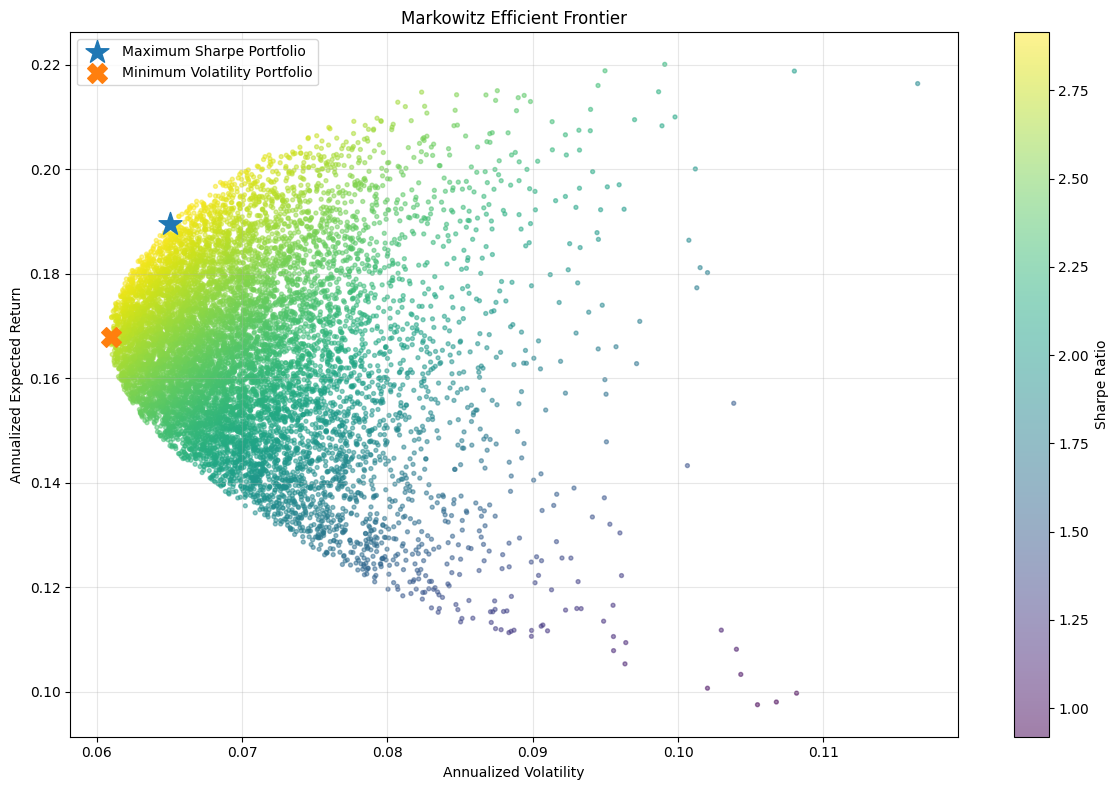

Efficient Frontier chart saved:
c:\Users\Keerthana\OneDrive\Documents\MutualFundAnalytics\reports\charts\markowitz_efficient_frontier.png


In [15]:
plt.figure(figsize=(12, 8))

scatter = plt.scatter(
    portfolio_df["Volatility"],
    portfolio_df["Return"],
    c=portfolio_df["Sharpe"],
    cmap="viridis",
    alpha=0.5,
    s=8
)

plt.colorbar(scatter, label="Sharpe Ratio")

# Maximum Sharpe portfolio
plt.scatter(
    max_sharpe_portfolio["Volatility"],
    max_sharpe_portfolio["Return"],
    marker="*",
    s=300,
    label="Maximum Sharpe Portfolio"
)

# Minimum volatility portfolio
plt.scatter(
    min_volatility_portfolio["Volatility"],
    min_volatility_portfolio["Return"],
    marker="X",
    s=200,
    label="Minimum Volatility Portfolio"
)

plt.xlabel("Annualized Volatility")
plt.ylabel("Annualized Expected Return")
plt.title("Markowitz Efficient Frontier")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

frontier_file = (
    CHART_DIR / "markowitz_efficient_frontier.png"
)

plt.savefig(
    frontier_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Efficient Frontier chart saved:")
print(frontier_file)

In [16]:
optimal_weights = pd.DataFrame({
    "Fund": fund_names,
    "Maximum Sharpe Weight": [
        max_sharpe_portfolio[fund]
        for fund in fund_names
    ],
    "Minimum Volatility Weight": [
        min_volatility_portfolio[fund]
        for fund in fund_names
    ]
})

optimal_weights

,Fund,Maximum Sharpe Weight,Minimum Volatility Weight
0,Nippon Large Cap,0.271553,0.196937
1,Axis Bluechip,0.062467,0.183977
2,SBI Bluechip,0.295237,0.229299
3,ICICI Bluechip,0.205177,0.180238
4,Kotak Bluechip,0.165565,0.209549


In [17]:
optimal_weights["Maximum Sharpe Weight"] = (
    optimal_weights["Maximum Sharpe Weight"] * 100
)

optimal_weights["Minimum Volatility Weight"] = (
    optimal_weights["Minimum Volatility Weight"] * 100
)

optimal_weights

,Fund,Maximum Sharpe Weight,Minimum Volatility Weight
0,Nippon Large Cap,27.155310,19.693712
1,Axis Bluechip,6.246717,18.397715
2,SBI Bluechip,29.523739,22.929907
3,ICICI Bluechip,20.517717,18.023761
4,Kotak Bluechip,16.556517,20.954906


In [18]:
weights_file = (
    OUTPUT_DIR / "markowitz_optimal_weights.csv"
)

optimal_weights.to_csv(
    weights_file,
    index=False
)

print("Portfolio weights saved successfully!")
print(weights_file)

Portfolio weights saved successfully!
c:\Users\Keerthana\OneDrive\Documents\MutualFundAnalytics\outputs\markowitz_optimal_weights.csv


In [19]:
portfolio_summary = pd.DataFrame({
    "Portfolio": [
        "Maximum Sharpe",
        "Minimum Volatility"
    ],
    "Expected Return": [
        max_sharpe_portfolio["Return"],
        min_volatility_portfolio["Return"]
    ],
    "Volatility": [
        max_sharpe_portfolio["Volatility"],
        min_volatility_portfolio["Volatility"]
    ],
    "Sharpe Ratio": [
        max_sharpe_portfolio["Sharpe"],
        min_volatility_portfolio["Sharpe"]
    ]
})

portfolio_summary

,Portfolio,Expected Return,Volatility,Sharpe Ratio
0,Maximum Sharpe,0.189596,0.065056,2.914322
1,Minimum Volatility,0.167914,0.060943,2.755280


In [20]:
summary_file = (
    OUTPUT_DIR / "markowitz_portfolio_summary.csv"
)

portfolio_summary.to_csv(
    summary_file,
    index=False
)

print("Portfolio summary saved successfully!")
print(summary_file)

Portfolio summary saved successfully!
c:\Users\Keerthana\OneDrive\Documents\MutualFundAnalytics\outputs\markowitz_portfolio_summary.csv


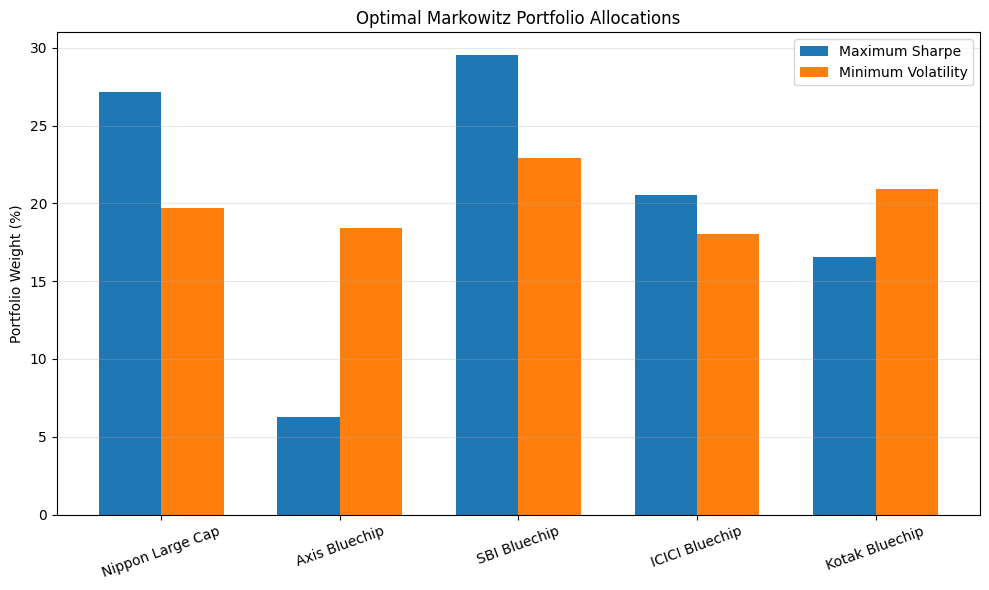

Weight chart saved:
c:\Users\Keerthana\OneDrive\Documents\MutualFundAnalytics\reports\charts\markowitz_portfolio_weights.png


In [21]:
plt.figure(figsize=(10, 6))

x = np.arange(len(fund_names))
width = 0.35

plt.bar(
    x - width / 2,
    optimal_weights["Maximum Sharpe Weight"],
    width,
    label="Maximum Sharpe"
)

plt.bar(
    x + width / 2,
    optimal_weights["Minimum Volatility Weight"],
    width,
    label="Minimum Volatility"
)

plt.xticks(
    x,
    fund_names,
    rotation=20
)

plt.ylabel("Portfolio Weight (%)")
plt.title("Optimal Markowitz Portfolio Allocations")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

weights_chart = (
    CHART_DIR / "markowitz_portfolio_weights.png"
)

plt.savefig(
    weights_chart,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Weight chart saved:")
print(weights_chart)

## Key Findings

- The Maximum Sharpe portfolio achieved an expected annualized return of approximately 18.96%.
- The Maximum Sharpe portfolio had an annualized volatility of approximately 6.51%.
- The Maximum Sharpe portfolio achieved a Sharpe ratio of approximately 2.91.
- The Minimum Volatility portfolio achieved an expected annualized return of approximately 16.79%.
- The Minimum Volatility portfolio had the lowest simulated portfolio volatility of approximately 6.09%.
- The Minimum Volatility portfolio achieved a Sharpe ratio of approximately 2.76.
- SBI Bluechip received the highest allocation in the Maximum Sharpe portfolio at approximately 29.52%.
- The results demonstrate the potential benefits of diversification across multiple mutual funds.
- The analysis is based on historical returns and should not be interpreted as a guarantee of future performance.

## Conclusion

The Markowitz analysis demonstrates how combining multiple mutual funds can produce portfolios with different risk-return characteristics.

The Maximum Sharpe portfolio provides the highest simulated risk-adjusted return, while the Minimum Volatility portfolio provides the lowest simulated risk.

These results can help investors understand the trade-off between portfolio risk and expected return.